# AI61201: Visual Computing with AI/ML
### **Programming Assignment 3**: Frequency-Domain Image Processing

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Question 1 — Gaussian Band Reject Filtering [6 Marks]

Input: `I1.png`

The input image for this question has the form 
$$
g(x, y) = f (x, y) + A sin [2π(u0x/M + v0y/N )]
$$

where f (x, y) is the clean grayscale image and g(x, y) is the corrupted image.

Use the supplied periodic-interference image and perform all operations using OpenCV DFT/IDFT functions.

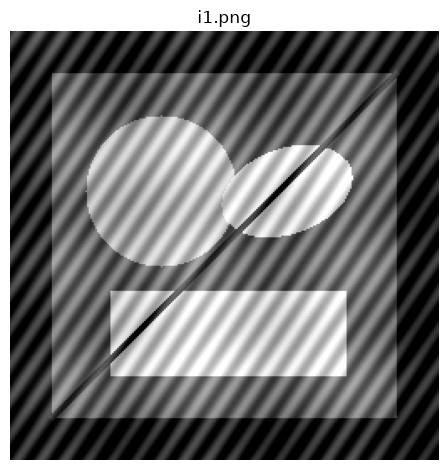

In [2]:
img1 = cv2.imread('resources/i1.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img1, cmap='gray')
plt.title("i1.png")
plt.axis("off")
plt.tight_layout()

### 1(a) [1.0] Compute the 2D DFT using OpenCV. Shift the spectrum so that the zero-frequency component is at the center and display log (1 + |F(u, v)|)

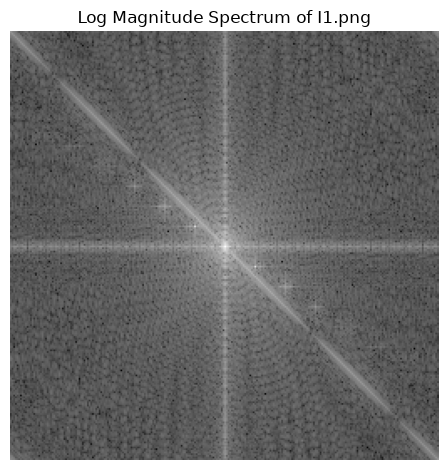

In [3]:
# compute 2-D DFT
dft = cv2.dft(np.float32(img1), flags=cv2.DFT_COMPLEX_OUTPUT)

# shift zero-frequency component to the center
dft_shift = np.fft.fftshift(dft)

# compute log(1 + |F(u,v)|)
magnitude = cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1])
log_magnitude = np.log(1 + magnitude)
log_magnitude = cv2.normalize(log_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.imshow(log_magnitude, cmap='gray')
plt.title('Log Magnitude Spectrum of I1.png')
plt.axis("off")
plt.tight_layout()
plt.show()

### 1(b) [1.5] From the centered magnitude spectrum, identify the frequency coordinates of the periodic interference. Explain how the symmetric peaks correspond to a real sinusoidal interference. Report the estimated frequency coordinates (u0, v0), using a clearly stated frequency-coordinate convention.

In [4]:
M, N = img1.shape 
center = (M // 2, N // 2)  
spectrum = magnitude.copy()  

spectrum[center[0] - 10 : center[0] + 11, center[1] - 10 : center[1] + 11] = 0      # Suppress the DC region
peak_coords = np.unravel_index(np.argsort(spectrum.ravel())[-2:], spectrum.shape)   # Find the two strongest peaks
freq_coords = [(x - N // 2, y - M // 2) for y, x in zip(*peak_coords)]              # Convert peak locations to frequency coordinates

print("Estimated frequency coordinates (u, v):", freq_coords)  

Estimated frequency coordinates (u, v): [(np.int64(-18), np.int64(-12)), (np.int64(18), np.int64(12))]


**Explanation**

Using the centered magnitude spectrum, the periodic-interference peaks are detected at:
$$
(u_0, v_0) = (18, 12)
$$
and its symmetric counterpart:
$$
(-u_0, -v_0) = (-18, -12)
$$

**Convention:** The centre of the shifted DFT is taken as $(0,0)$, with horizontal displacement as $u$ and vertical displacement as $v$.

The symmetric peaks occur because a real sinusoidal interference contains two complex exponentials with opposite frequencies, producing peaks at $(u_0,v_0)$ and $(-u_0,-v_0)$.

### 1(c) [1.5] Design a Gaussian band-reject filter with suitable low/high cut-off frequencies (or equivalently a center frequency and bandwidth). Display the filter as an image. Explain why your chosen pass/reject region removes the interference while preserving as much image content as possible.

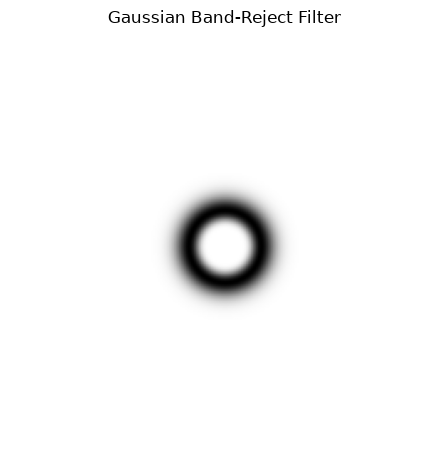

In [5]:
M, N = img1.shape  

# Create centered frequency coordinates
u = np.arange(N) - N // 2  
v = np.arange(M) - M // 2  
U, V = np.meshgrid(u, v)  

D = np.sqrt(U**2 + V**2)        
u0, v0 = freq_coords[-1]        # Get the detected interference frequency
D0 = np.sqrt(u0**2 + v0**2)     # Calculate the center frequency of the interference
W = 10                          # Set the bandwidth of the rejected frequency band

D_safe = np.where(D == 0, 1, D)                                 # Replace zero distance to avoid division by zero
H = 1 - np.exp(-((D_safe**2 - D0**2) / (D_safe * W))**2 / 2)    # Gaussian band-reject filter
H[D == 0] = 1                                                   # Preserve the DC component

plt.imshow(H, cmap='gray')
plt.title("Gaussian Band-Reject Filter")
plt.axis("off")
plt.tight_layout()

**Explanation**

The interference peaks occur at a `radial frequency D_0` from the spectrum centre. The Gaussian band-reject filter attenuates a narrow band around D_0, thereby suppressing the periodic interference.

A relatively small bandwidth `W = 10` is chosen so that only frequencies close to the interference frequency are rejected. Frequencies outside this band are largely preserved, retaining most of the image's useful frequency content and minimizing loss of image details.

### 1(d) [1.0] Apply the designed Gaussian band-reject filter in the frequency domain. Show the filtered spectrum and/or the filtered complex DFT before IDFT, and briefly explain the operation.

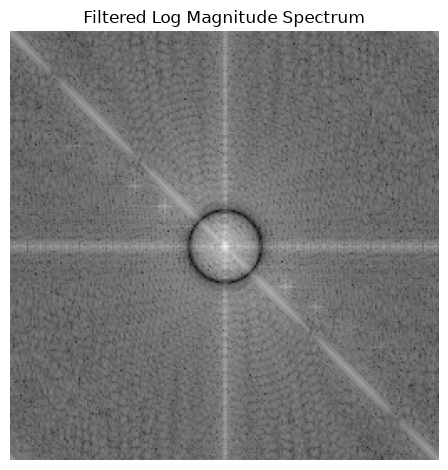

In [6]:
# Apply the filter to the real and imaginary DFT components
filtered_dft = dft_shift * H[:, :, np.newaxis]  
filtered_magnitude = cv2.magnitude(filtered_dft[:, :, 0], filtered_dft[:, :, 1])  

# Compute log magnitude for visualization
filtered_log = np.log(1 + filtered_magnitude)  
filtered_log = cv2.normalize(filtered_log, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) 

# Display the filtered spectrum
plt.imshow(filtered_log, cmap='gray')  
plt.title("Filtered Log Magnitude Spectrum")
plt.axis("off")
plt.tight_layout()
plt.show()

**Explanation**

The centered complex DFT is multiplied element-wise by the Gaussian band-reject filter:
$$
F_{\text{filtered}}(u,v)=F(u,v)H(u,v).
$$

The Gaussian band-reject filter is given by:
$$
H(u,v)=1-\exp\left[-\frac{1}{2}
\left(\frac{D^2(u,v)-D_0^2}{D(u,v)W}\right)^2\right],
$$

where
$$
D(u,v)=\sqrt{u^2+v^2}.
$$

Here, D_0 is the center frequency of the rejected band and W is its bandwidth.


### 1(e) [1.0] Take the 2D IDFT using OpenCV functions and display the restored image. Compare it qualitatively with the corrupted image and comment on residual interference and image-detail loss.

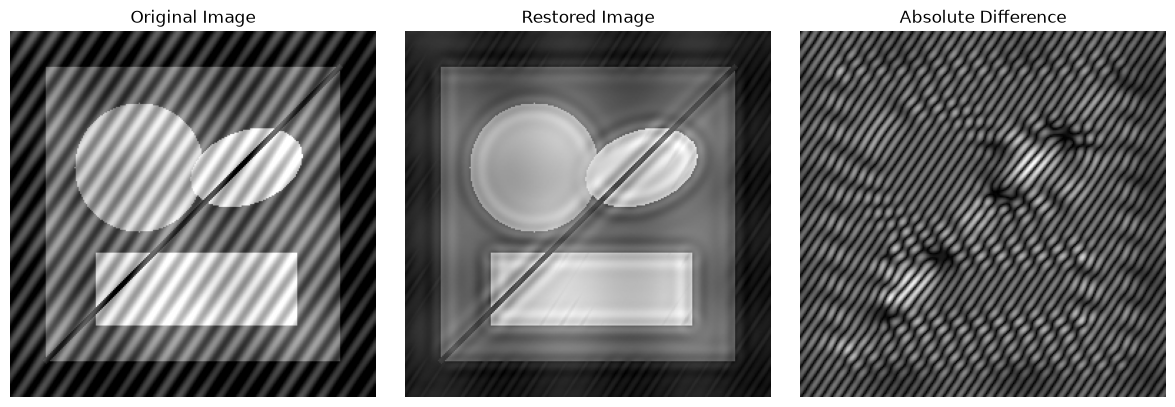

In [7]:
#  Take the 2D IDFT 
filtered_dft_unshifted = np.fft.ifftshift(filtered_dft)
restored_complex = cv2.idft(filtered_dft_unshifted, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
restored_img1 = np.clip(restored_complex, 0, 255).astype(np.uint8)

# Display the restored image
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap="gray"); plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored_img1, cmap="gray"); plt.title("Restored Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(img1.astype(float) - restored_img1.astype(float)), cmap="gray")
plt.title("Absolute Difference")
plt.axis("off")
plt.tight_layout()

**Observation**

The restored image shows ***reduced diagonal interference***, but ***ringing artifacts remain*** around sharp edges due to the frequency-selective band-reject filter. Some fine image details are also lost due to attenuation of nearby frequency components.

## Question 2 — Translating an Image by Manipulating Its DFT [4 Marks]

Input: `I2.png`

Use NumPy's `np.fft.fft2` implementation. Let the desired horizontal and vertical translations be x0 = 25 (i.e
shifted right by 25 pixels) and y0 = −15 (i.e. shifted upwards by 15 pixels).


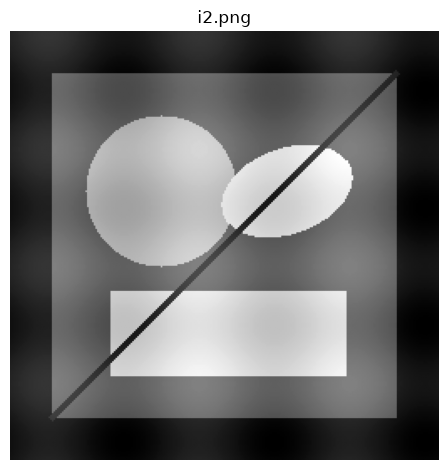

In [8]:
img2 = cv2.imread('resources/i2.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img2, cmap='gray')
plt.title("i2.png")
plt.axis("off")
plt.tight_layout()

### 2(a) [1.0] Compute the 2D DFT and display the zero-centered log-magnitude spectrum and phase spectrum.

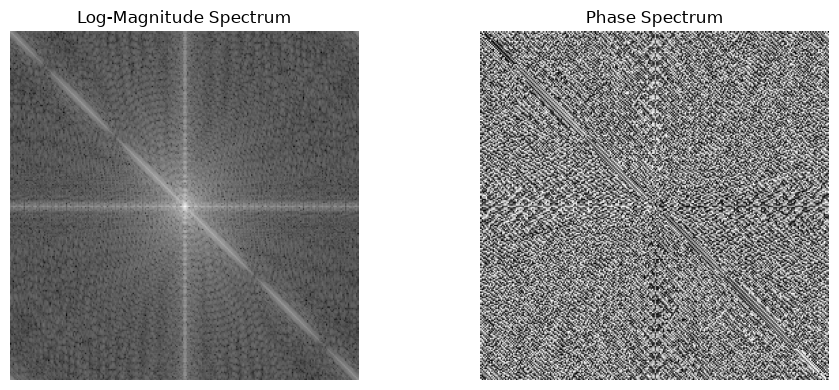

In [9]:
# Compute the 2D DFT and display the zero-centered log-magnitude and phase spectra
dft = np.fft.fft2(img2)
dft_shifted = np.fft.fftshift(dft)  # zero-centred for visualization

magnitude_spectrum = np.log1p(np.abs(dft_shifted))
phase_spectrum = np.angle(dft_shifted)

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Log-Magnitude Spectrum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(phase_spectrum, cmap="gray")
plt.title("Phase Spectrum")
plt.axis("off")
plt.tight_layout()

### 2(b) [1.0] Apply the appropriate Fourier-domain transformation to translate the image horizontally by x0 and vertically by y0. Decide whether the magnitude, phase, or both must be modified. State the mathematical transformation and implement it.

**Approach**

***Only the phase*** must be modified, the ***magnitude remains unchanged***.
$$
G(u,v)=F(u,v)\exp\left[-j2\pi\left(\frac{ux_0}{N}+\frac{vy_0}{M}\right)\right]
$$
For `x0 = 25, y0 = -15`, the phase is shifted to translate the image right by 25 pixels and upward by 15 pixels.


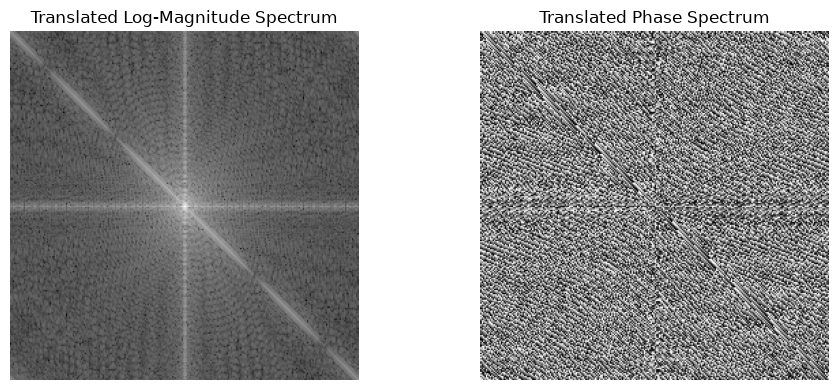

In [10]:
# Apply Fourier-domain translation
x0, y0 = 25, -15
M, N = img2.shape
u = np.arange(N)
v = np.arange(M)
U, V = np.meshgrid(u, v)

phase_shift = np.exp(-1j * 2 * np.pi * (U * x0 / N + V * y0 / M))
translated_dft = dft * phase_shift

# Display
translated_dft_shifted = np.fft.fftshift(translated_dft)
translated_magnitude = np.log1p(np.abs(translated_dft_shifted))
translated_phase = np.angle(translated_dft_shifted)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(translated_magnitude, cmap="gray")
plt.title("Translated Log-Magnitude Spectrum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated_phase, cmap="gray")
plt.title("Translated Phase Spectrum")
plt.axis("off")
plt.tight_layout()
plt.show()

### 2(c) [1.0] Take the IDFT of the transformed DFT and display the translated image. Verify visually that the requested displacement occurred.

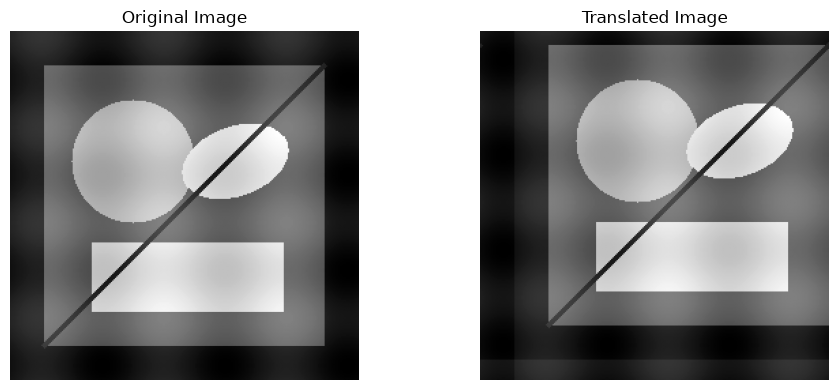

In [11]:
# Take the IDFT of the transformed DFT
translated_img = np.real(np.fft.ifft2(translated_dft))

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated_img, cmap="gray")
plt.title("Translated Image")
plt.axis("off")
plt.tight_layout()

**Observation**

The translated image is visually shifted ***25 pixels to the right and 15 pixels upward***, confirming that the desired displacement has occurred.

### 2(d) [1.0] Explain, using the polar form 

$$
F(u,v)=|F(u,v)|e^{j\phi(u,v)}
$$
why the transformation you applied changes phase while leaving the magnitude unchanged (apart from numerical effects).

**Explanation**

The Fourier-domain translation multiplies the DFT by a unit-magnitude phase factor:
$$
G(u,v)=F(u,v)\exp\left[-j2\pi\left(\frac{ux_0}{N}+\frac{vy_0}{M}\right)\right].
$$

Using the polar form,
$$
F(u,v)=|F(u,v)|\exp\left[j\phi(u,v)\right],
$$

we get
$$
G(u,v)=|F(u,v)|\exp\left[j\left(\phi(u,v)-2\pi\left(\frac{ux_0}{N}+\frac{vy_0}{M}\right)\right)\right].
$$

Since the phase factor has ***unit magnitude***, it only ***adds a phase shift*** to the DFT coefficients and does not change their magnitude.

## Question 3 — Rotating an Image by 180° using Its DFT [3 Marks]

Input: `I2.png`

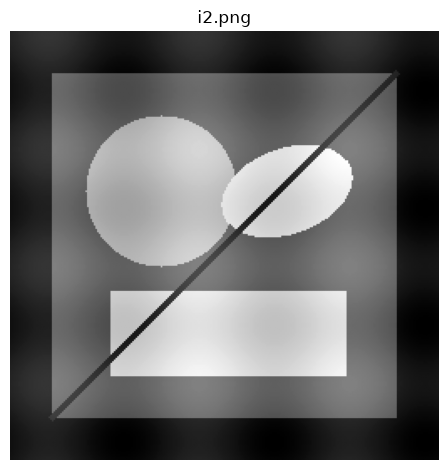

In [12]:
plt.imshow(img2, cmap='gray')
plt.title("i2.png")
plt.axis("off")
plt.tight_layout()

### 3(a) [2.0] Apply a suitable transformation to the DFT to obtain a 180° spatial rotation. Decide whether the magnitude spectrum, phase spectrum, or both must be transformed. State the mathematical transformation you use and explain the discrete-coordinate convention carefully.

**Approach**

For a 180° rotation in the spatial domain,

$$
g[y,x]=f[M-1-y,\;N-1-x],
$$

where $M$ and $N$ are the image height and width, respectively.

The corresponding DFT transformation is

$$
G[v,u]=F[(-v)\bmod M,\;(-u)\bmod N].
$$

Thus, ***both the magnitude and phase spectra are transformed*** by reindexing the DFT coefficients according to the above relation. The magnitude spectrum is centrosymmetric for a real-valued image, so its appearance remains essentially unchanged after this transformation, while the phase spectrum is correspondingly reindexed.

Here, the DFT uses zero-based discrete frequency indices:

$$
u=0,1,\ldots,N-1,\qquad v=0,1,\ldots,M-1.
$$

The negative frequency indices are represented using modulo indexing. For example,

$$
(-u)\bmod N =
\begin{cases}
0, & u=0,\\
N-u, & u>0.
\end{cases}
$$

Similarly,

$$
(-v)\bmod M =
\begin{cases}
0, & v=0,\\
M-v, & v>0.
\end{cases}
$$

Therefore, the zero-frequency component remains at $(0,0)$, while every non-zero frequency component is mapped to its corresponding negative-frequency location. This modulo convention is necessary because the DFT indices are stored in the range $0$ to $N-1$ and $0$ to $M-1$, even though the underlying frequency domain is periodic. :contentReference[oaicite:0]{index=0}

In [13]:
# Compute the 2D DFT and apply 180° rotation
dft3 = np.fft.fft2(img2)
M, N = img2.shape

v = np.arange(M)
u = np.arange(N)
V, U = np.meshgrid(v, u, indexing="ij")

rotated_dft = dft3[(-V) % M, (-U) % N]

### 3(b) [1.0] Take the IDFT of the transformed DFT and display the 180°-rotated image. Confirm that the result corresponds to a spatial 180° rotation.

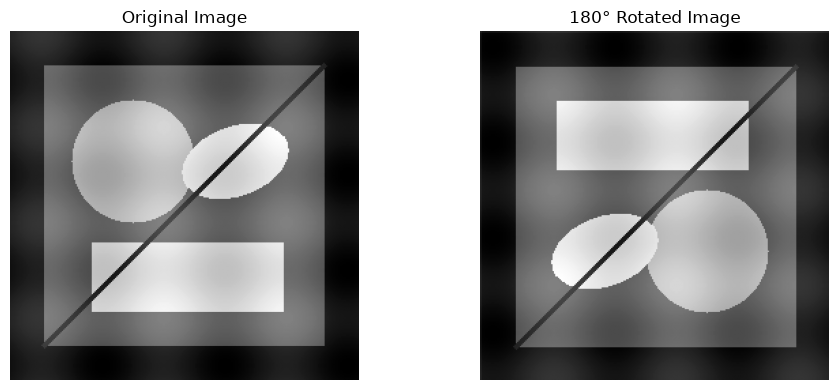

In [14]:
# Take Inverse DFT
rotated_img = np.real(np.fft.ifft2(rotated_dft))

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated_img, cmap="gray")
plt.title("180° Rotated Image")
plt.axis("off")
plt.tight_layout()

**Observation**

The IDFT of the transformed DFT produces an image that is visually equivalent to a ***180° rotation of the original image***, confirming that the frequency-domain transformation correctly achieves the desired spatial rotation.

## Question 4 — Discrete Cosine Transform [7 Marks]

Input: `I3.png`

Use the supplied DCT image. Implement the DCT from scratch in a separable manner.

For an MxN image, use the following definition:
$$
C(u,v)=\alpha(u)\alpha(v)
\sum_{x=0}^{M-1}\sum_{y=0}^{N-1}
f(x,y)
\cos\left[\frac{\pi(2x+1)u}{2M}\right]
\cos\left[\frac{\pi(2y+1)v}{2N}\right]
$$

where
$$
\alpha(u)=
\begin{cases}
\sqrt{\frac{1}{M}}, & u=0\\[4pt]
\sqrt{\frac{2}{M}}, & u\neq0
\end{cases}
$$

$$
\alpha(v)=
\begin{cases}
\sqrt{\frac{1}{N}}, & v=0\\[4pt]
\sqrt{\frac{2}{N}}, & v\neq0
\end{cases}
$$

The inverse DCT is given by

$$
f(x,y)=
\sum_{u=0}^{M-1}\sum_{v=0}^{N-1}
\alpha(u)\alpha(v)C(u,v)
\cos\left[\frac{\pi(2x+1)u}{2M}\right]
\cos\left[\frac{\pi(2y+1)v}{2N}\right]
$$

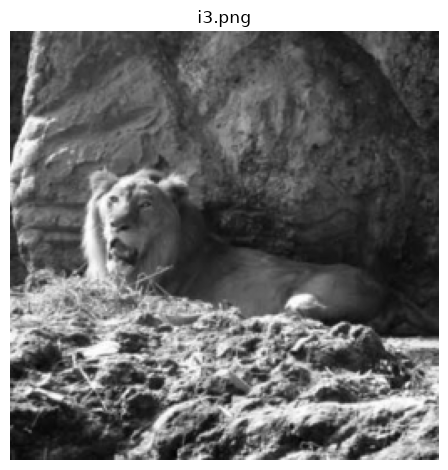

In [15]:
img3 = cv2.imread('resources/i3.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img3, cmap='gray')
plt.title("i3.png")
plt.axis("off")
plt.tight_layout()

### 4(a) [2.0] Implement the 2D DCT from scratch in a separable manner. A recommended structure is: apply a 1D DCT to every row, then apply the same 1D DCT to every column. Do not call `cv2.dct` inside your fromscratch function.

In [16]:
def dct_1d(x):
    """
    Compute the 1D DCT of a vector from scratch.
    """
    N = len(x)
    dct_1d = np.zeros(N, dtype=np.float64)

    for k in range(N):
        alpha = np.sqrt(1 / N) if k == 0 else np.sqrt(2 / N)
        for n in range(N):
            dct_1d[k] += x[n] * np.cos(np.pi * (2 * n + 1) * k / (2 * N))
        dct_1d[k] *= alpha
    return dct_1d


def dct_2d(image):
    """
    Compute the 2D DCT from scratch using separability.
    1. Apply 1D DCT to every row.
    2. Apply 1D DCT to every column.
    """
    image = image.astype(np.float64)

    # Step 1: DCT along rows
    row_dct = np.zeros_like(image)
    for i in range(image.shape[0]):
        row_dct[i, :] = dct_1d(image[i, :])

    # Step 2: DCT along columns
    dct_2d = np.zeros_like(row_dct)
    for j in range(image.shape[1]):
        dct_2d[:, j] = dct_1d(row_dct[:, j])

    return dct_2d

# Compute 2-D DCT of the image
dct_scratch = dct_2d(img3)

### 4(b) [0.5] Verify your implementation against OpenCV's `cv2.dct`. Report the maximum absolute difference (or another clearly defined numerical error metric) and state whether the implementations agree within numerical precision.

In [17]:
# OpenCV DCT 
dct_cv = cv2.dct(img3.astype(np.float64))

# Maximum absolute difference
max_abs_diff = np.max(np.abs(dct_scratch - dct_cv))
print("Maximum Absolute Difference:", max_abs_diff)

Maximum Absolute Difference: 1.2613732280897239e-10


**Observation**

The ***maximum absolute difference*** between the `from-scratch 2D DCT` and `OpenCV's cv2.dct()` is in the order of $10^{-10}$, which is ***negligibly small***. Therefore, the ***two implementations agree*** within numerical precision.

### 4(c) [0.5] Visualize the DCT coefficient matrix after a logarithmic transformation, e.g. log(1+|C(u,v)|).

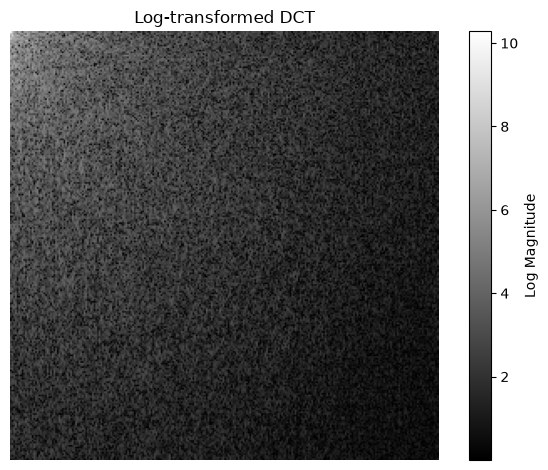

In [18]:
# Logarithmic transformation of DCT coefficients
dct_log = np.log1p(np.abs(dct_scratch))

# Display
plt.imshow(dct_log, cmap="gray")
plt.title("Log-transformed DCT")
plt.axis("off")
plt.colorbar(label="Log Magnitude")
plt.tight_layout()

### 4(d) [1.0] For each radial frequency r, calculate the fraction of total DCT energy contained inside that radius:
$$
E(r) =
\frac{
\displaystyle \sum_{u,v:\,u^2+v^2\leq r^2} |C(u,v)|^2
}{
\displaystyle \sum_{u,v} |C(u,v)|^2
}.
$$
Plot E(r) as a function of r.

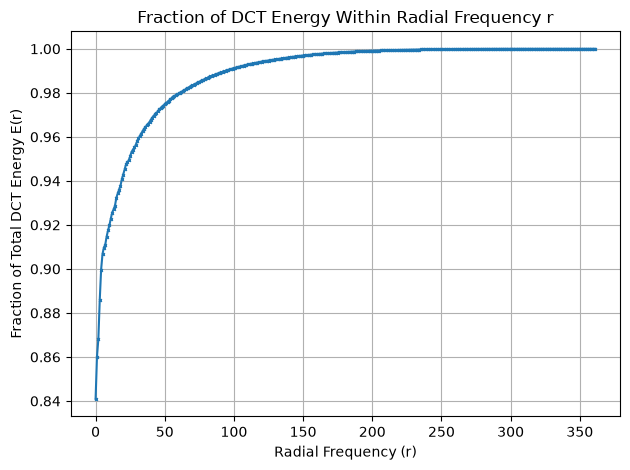

In [19]:
# Fraction of  DCT energy
dct_energy = np.abs(dct_scratch) ** 2
total_energy = np.sum(dct_energy)

# Coordinate grid
rows, cols = dct_scratch.shape
u, v = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
radius = np.sqrt(u**2 + v**2)      # Radial frequency
max_r = int(np.ceil(np.max(radius)))

# Calculate E(r) for each integer radius
r_values = np.arange(max_r + 1)
energy_fraction = []

for r in r_values:
    mask = radius <= r
    energy_inside = np.sum(dct_energy[mask])
    E_r = energy_inside / total_energy
    energy_fraction.append(E_r)

energy_fraction = np.array(energy_fraction)

# Plot E(r) versus r
plt.plot(r_values, energy_fraction, marker="x", markersize=2)
plt.title("Fraction of DCT Energy Within Radial Frequency r")
plt.xlabel("Radial Frequency (r)")
plt.ylabel("Fraction of Total DCT Energy E(r)")
plt.grid(True)
plt.tight_layout()

### 4(e) [1.0] Select the smallest suitable radial threshold r such that at least 97.5% of the total DCT energy is retained. Report the threshold value and the corresponding retained energy.

In [20]:
# Find the smallest radial threshold retaining at least 97.5% energy
target_energy = 0.975
idx = np.where(energy_fraction >= target_energy)[0][0]
r_threshold = r_values[idx]
retained_energy = energy_fraction[idx]

print(f"Smallest radial threshold r = {r_threshold}")
print(f"Retained DCT energy = {retained_energy * 100:.4f}%")

Smallest radial threshold r = 51
Retained DCT energy = 97.5401%


### 4(f) [2.0] Set all DCT coefficients with r greater than the threshold to zero and perform the inverse DCT. Report the fraction of all DCT coefficients that are thus set to 0. Reconstruct the image by performing inverse DCT. Display the reconstructed image and the absolute difference between the original and the reconstructed images. Explain why the absolute difference is high in certain regions of the image, relating your explanation to edges, fine details, and discarded high-frequency coefficients.

In [21]:
# Set coefficients outside the selected radial threshold to zero
dct_copy = dct_scratch.copy()
mask = radius > r_threshold
dct_copy[mask] = 0

# Fraction of DCT coefficients set to zero
num_zeroed = np.sum(mask)
total_coefficients = dct_scratch.size
zero_fraction = num_zeroed / total_coefficients
print(f"Fraction of coefficients set to zero = {zero_fraction:.4f}")

Fraction of coefficients set to zero = 0.9680


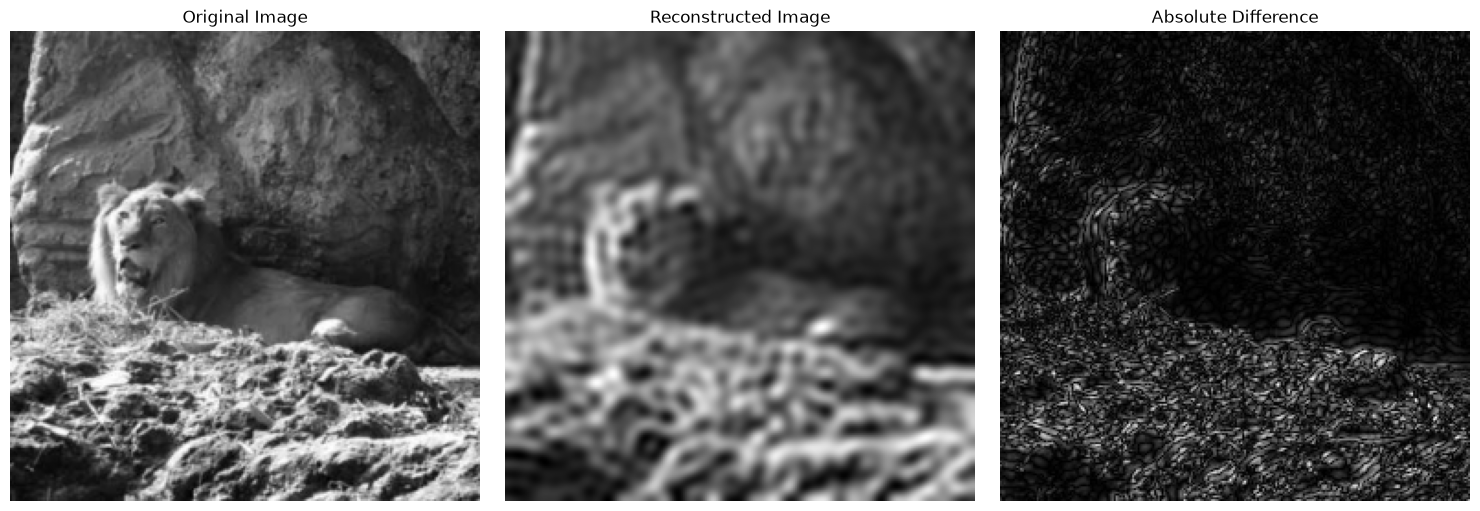

In [22]:
# Reconstruct image using inverse DCT
reconstructed = cv2.idct(dct_copy)
absolute_difference = np.abs(img3.astype(np.float64) - reconstructed)

# Display
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img3, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(absolute_difference, cmap="gray")
plt.title("Absolute Difference")
plt.axis("off")
plt.tight_layout()

**Explanation**

The absolute difference is higher in certain regions because ***edges, fine details, and textures contain significant high-frequency components*** in the DCT representation. When DCT coefficients with radial frequency $(r > r_{\text{threshold}})$ are set to zero, these high-frequency components are discarded.

As a result, smooth regions, which are mainly represented by low-frequency coefficients, are reconstructed with relatively small error. In contrast, sharp edges and fine details require higher-frequency coefficients to represent their rapid intensity variations. Removing these coefficients causes loss of edge sharpness and fine details, producing larger absolute differences in those regions.

Thus, although at least 97.5% of the total DCT energy is retained, the discarded high-frequency coefficients still have a noticeable local effect, particularly around ***edges, textures, and fine image details***.

---
End of the assignment